# Análisis de Operadores — Primer Experimento

Cargamos todos los CSV del experimento `random_seed_w_params_20260427_214859` y
analizamos cuántas veces cada operador de vecindario produjo una **mejora**,
agregando **todas las instancias** y configuraciones.

In [4]:
import pathlib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

EXPERIMENTO = pathlib.Path(
    "/home/alhely/Desktop/CARP/Code/MetaCARP_Proyecto/metacarp/"
    "scripts/experimentos/random_seed_w_params_20260427_214859"
)

OPERADORES = [
    "relocate_intra",
    "swap_intra",
    "2opt_intra",
    "relocate_inter",
    "swap_inter",
    "2opt_star",
    "cross_exchange",
]

CATEGORIAS = ["propuesto", "aceptado", "mejoraron", "trayectoria_mejor"]

METAS = ["sa", "tabu", "abejas", "cuckoo"]

In [5]:
frames = []
for meta in METAS:
    carpeta = EXPERIMENTO / meta
    for csv_path in sorted(carpeta.glob("*.csv")):
        df = pd.read_csv(csv_path)
        frames.append(df)

df_all = pd.concat(frames, ignore_index=True)
print(f"Total de corridas cargadas: {len(df_all)}")
print(f"Metaheurísticas: {df_all['metaheuristica'].unique().tolist()}")
print(f"Instancias:      {sorted(df_all['instancia'].unique())}")
df_all.head(2)

Total de corridas cargadas: 16284
Metaheurísticas: ['recocido_simulado', 'busqueda_tabu', 'busqueda_abejas', 'cuckoo_search']
Instancias:      ['gdb1', 'gdb10', 'gdb12', 'gdb13', 'gdb14', 'gdb15', 'gdb16', 'gdb17', 'gdb19', 'gdb2', 'gdb20', 'gdb21', 'gdb3', 'gdb4', 'gdb5', 'gdb6', 'gdb7', 'kshs1', 'kshs2', 'kshs3', 'kshs4', 'kshs5', 'kshs6']


,metaheuristica,instancia,id_corrida,config_id,repeticion,semilla,backend_evaluacion_solicitado,backend_evaluacion_real,tiempo_segundos,iteraciones_totales,...,scouts_reinicios,param_num_fuentes,param_limite_abandono,nidos,abandonos_totales,reemplazos_exitosos,param_num_nidos,param_pa_abandono,param_pasos_levy_base,param_beta_levy
0,recocido_simulado,gdb10,gdb10-sa-cfg1-rep1-seed2118688860,sa-cfg1,1,2118688860,gpu,gpu,0.139123,2400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,recocido_simulado,gdb10,gdb10-sa-cfg1-rep2-seed2118688861,sa-cfg1,2,2118688861,gpu,gpu,0.139374,2400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Total de mejoras por operador (todas las metaheurísticas juntas)

In [6]:
cols_mejoraron = [f"mejoraron_{op}" for op in OPERADORES]
cols_propuesto = [f"propuesto_{op}" for op in OPERADORES]
cols_aceptado  = [f"aceptado_{op}"  for op in OPERADORES]

for c in cols_mejoraron + cols_propuesto + cols_aceptado:
    df_all[c] = pd.to_numeric(df_all[c], errors="coerce").fillna(0).astype(int)

total_mejoras = df_all[cols_mejoraron].sum().rename(lambda c: c.replace("mejoraron_", ""))
total_propuesto = df_all[cols_propuesto].sum().rename(lambda c: c.replace("propuesto_", ""))
total_aceptado = df_all[cols_aceptado].sum().rename(lambda c: c.replace("aceptado_", ""))

resumen = pd.DataFrame({
    "propuestos": total_propuesto,
    "aceptados": total_aceptado,
    "mejoras": total_mejoras,
})
resumen["tasa_mejora_%"] = (resumen["mejoras"] / resumen["propuestos"] * 100).round(3)
resumen["tasa_aceptacion_%"] = (resumen["aceptados"] / resumen["propuestos"] * 100).round(3)
resumen = resumen.sort_values("mejoras", ascending=False)
resumen

,propuestos,aceptados,mejoras,tasa_mejora_%,tasa_aceptacion_%
2opt_intra,89009820,9150622,35066,0.039,10.280
swap_intra,89006152,9143071,34710,0.039,10.272
relocate_intra,67854303,7203230,31000,0.046,10.616
swap_inter,89015736,8152664,24916,0.028,9.159
cross_exchange,89001865,7505577,18378,0.021,8.433
2opt_star,89008110,7288817,16126,0.018,8.189
relocate_inter,68810940,5581216,13327,0.019,8.111


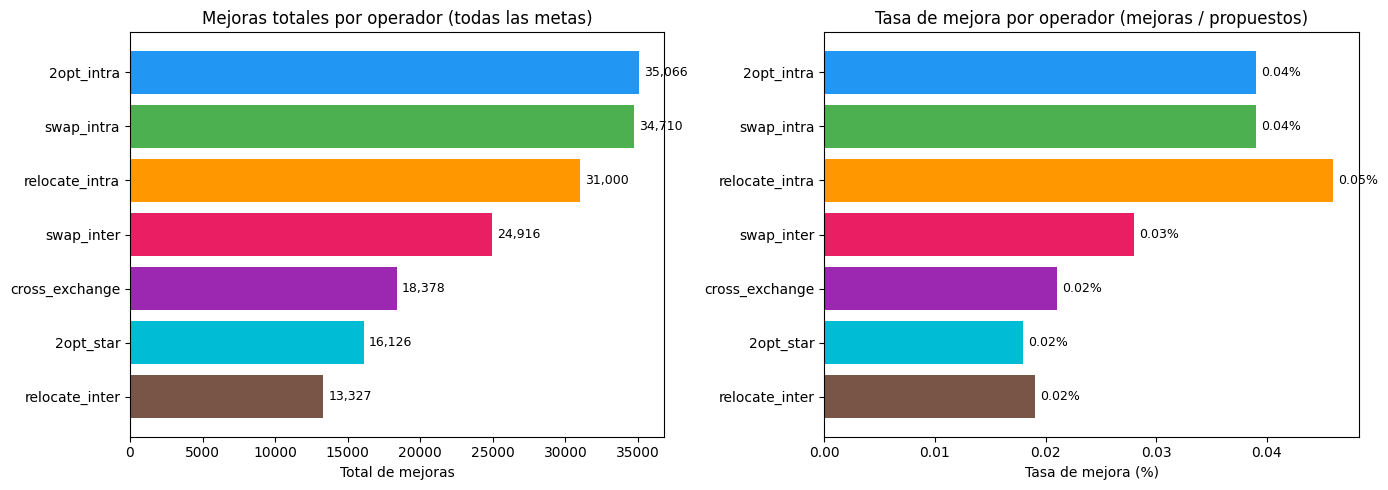

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63", "#9C27B0", "#00BCD4", "#795548"]

ax = axes[0]
bars = ax.barh(resumen.index, resumen["mejoras"], color=colores[:len(resumen)])
ax.set_xlabel("Total de mejoras")
ax.set_title("Mejoras totales por operador (todas las metas)")
ax.invert_yaxis()
for bar, val in zip(bars, resumen["mejoras"]):
    ax.text(bar.get_width() + max(resumen["mejoras"]) * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=9)

ax = axes[1]
bars = ax.barh(resumen.index, resumen["tasa_mejora_%"], color=colores[:len(resumen)])
ax.set_xlabel("Tasa de mejora (%)")
ax.set_title("Tasa de mejora por operador (mejoras / propuestos)")
ax.invert_yaxis()
for bar, val in zip(bars, resumen["tasa_mejora_%"]):
    ax.text(bar.get_width() + max(resumen["tasa_mejora_%"]) * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

## 2. Mejoras por operador, desglosado por metaheurística

In [8]:
mejoras_por_meta = (
    df_all.groupby("metaheuristica")[cols_mejoraron]
    .sum()
    .rename(columns=lambda c: c.replace("mejoraron_", ""))
)
mejoras_por_meta

,relocate_intra,swap_intra,2opt_intra,relocate_inter,swap_inter,2opt_star,cross_exchange
metaheuristica,,,,,,,
busqueda_abejas,4054,4556,4729,2197,4226,2505,3000
busqueda_tabu,4585,4211,4207,1799,3801,2419,2587
cuckoo_search,13269,15910,16024,6677,11475,8333,9206
recocido_simulado,9092,10033,10106,2654,5414,2869,3585


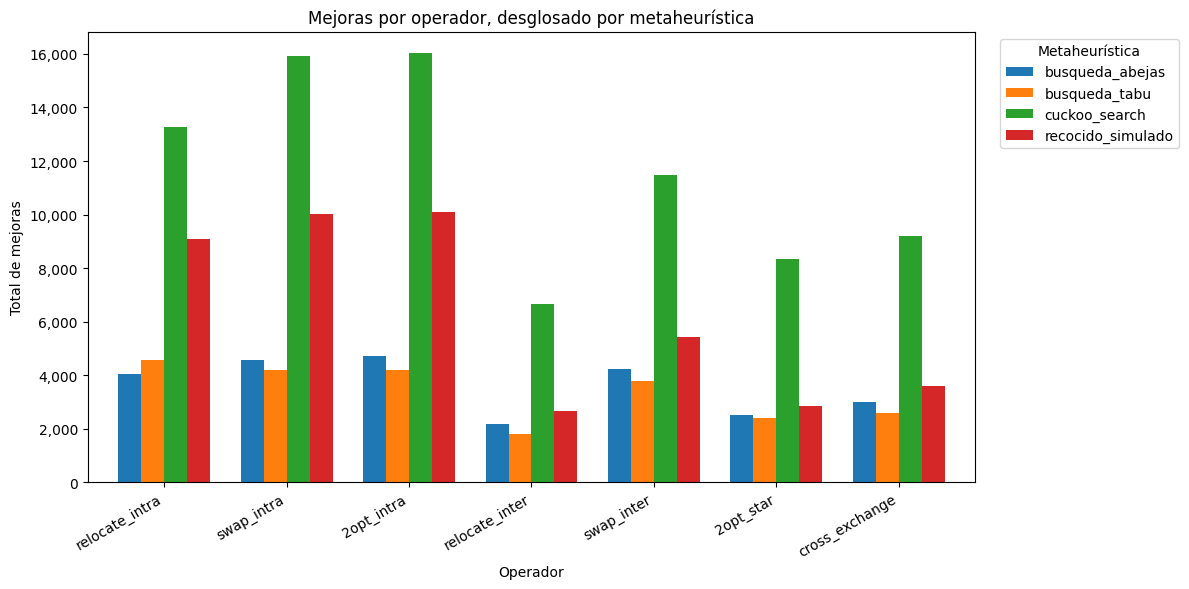

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
mejoras_por_meta.T.plot(kind="bar", ax=ax, width=0.75)
ax.set_ylabel("Total de mejoras")
ax.set_xlabel("Operador")
ax.set_title("Mejoras por operador, desglosado por metaheurística")
ax.legend(title="Metaheurística", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 3. Tasa de mejora por operador y metaheurística

In [10]:
propuestos_por_meta = (
    df_all.groupby("metaheuristica")[cols_propuesto]
    .sum()
    .rename(columns=lambda c: c.replace("propuesto_", ""))
)

tasa_mejora = (mejoras_por_meta / propuestos_por_meta * 100).round(3)
tasa_mejora

,relocate_intra,swap_intra,2opt_intra,relocate_inter,swap_inter,2opt_star,cross_exchange
metaheuristica,,,,,,,
busqueda_abejas,0.051,0.044,0.046,0.027,0.041,0.024,0.029
busqueda_tabu,0.079,0.055,0.055,0.031,0.050,0.032,0.034
cuckoo_search,0.026,0.024,0.024,0.013,0.017,0.012,0.014
recocido_simulado,0.275,0.232,0.234,0.079,0.125,0.066,0.083


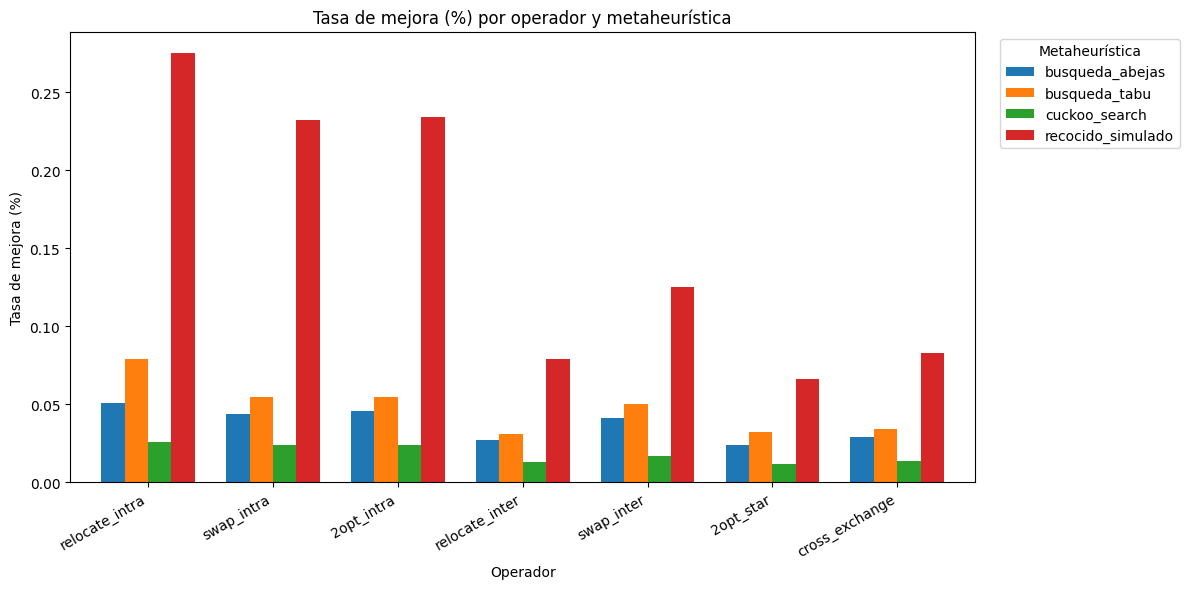

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
tasa_mejora.T.plot(kind="bar", ax=ax, width=0.75)
ax.set_ylabel("Tasa de mejora (%)")
ax.set_xlabel("Operador")
ax.set_title("Tasa de mejora (%) por operador y metaheurística")
ax.legend(title="Metaheurística", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 4. Proporción de mejoras por operador (global)

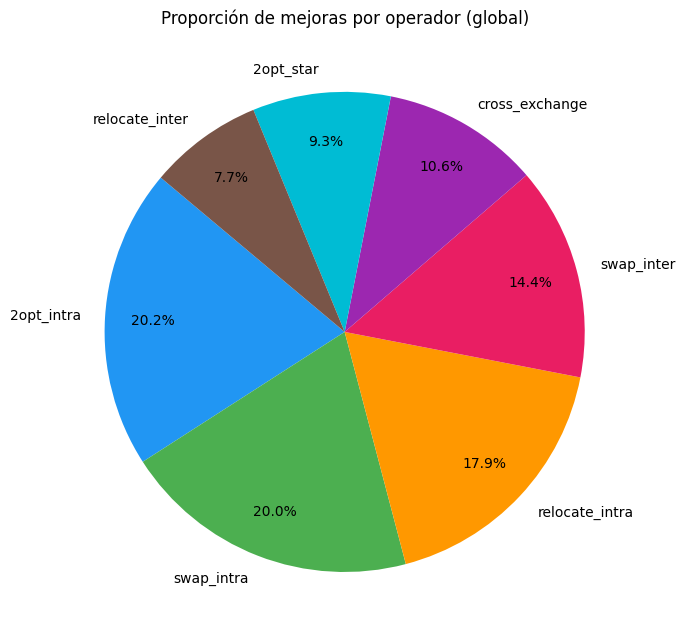

In [12]:
prop_mejoras = resumen["mejoras"] / resumen["mejoras"].sum() * 100

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    prop_mejoras,
    labels=prop_mejoras.index,
    autopct="%1.1f%%",
    colors=colores[:len(prop_mejoras)],
    startangle=140,
    pctdistance=0.8,
)
ax.set_title("Proporción de mejoras por operador (global)")
plt.tight_layout()
plt.show()

## 5. Resumen numérico completo

In [15]:
# Sin jinja2, pandas no expone .style; mostramos el mismo resumen formateado a mano.
resumen_completo = resumen.copy()
resumen_completo["mejoras_pct_del_total"] = (
    resumen_completo["mejoras"] / resumen_completo["mejoras"].sum() * 100
).round(2)

def _formatear_resumen(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for c in ("propuestos", "aceptados", "mejoras"):
        out[c] = out[c].map(lambda x: f"{int(x):,}")
    out["tasa_mejora_%"] = out["tasa_mejora_%"].map(lambda x: f"{x:.3f}")
    out["tasa_aceptacion_%"] = out["tasa_aceptacion_%"].map(lambda x: f"{x:.3f}")
    out["mejoras_pct_del_total"] = out["mejoras_pct_del_total"].map(lambda x: f"{x:.2f}")
    return out

_formatear_resumen(resumen_completo)

,propuestos,aceptados,mejoras,tasa_mejora_%,tasa_aceptacion_%,mejoras_pct_del_total
2opt_intra,"89,009,820","9,150,622","35,066",0.039,10.280,20.21
swap_intra,"89,006,152","9,143,071","34,710",0.039,10.272,20.00
relocate_intra,"67,854,303","7,203,230","31,000",0.046,10.616,17.87
swap_inter,"89,015,736","8,152,664","24,916",0.028,9.159,14.36
cross_exchange,"89,001,865","7,505,577","18,378",0.021,8.433,10.59
2opt_star,"89,008,110","7,288,817","16,126",0.018,8.189,9.29
relocate_inter,"68,810,940","5,581,216","13,327",0.019,8.111,7.68
